# Steam-200k: from raw activity to an evaluation split

**Data pipeline review · checkpoint 1**

This notebook follows every decision between the original Steam CSV and the saved
training/test files. We will inspect the source, account for every removed row,
examine engagement and user coverage, and trace a real user's held-out game.

The unit of modeling is **one user's accumulated hours on one game**, not one CSV
row. A purchase and a play record for the same game therefore do not represent two
training examples.

**Run:** install the project with `python -m pip install -e ".[eda]"`, run
`python -m src.data`, then select that environment as this notebook's Python kernel.
The saved notebook includes executed tables and plots for immediate review.
Re-running reads local data; it does not download data or overwrite pipeline outputs.

Source: [Tamber's Steam Video Games dataset, version 3](https://www.kaggle.com/datasets/tamber/steam-video-games).
Its lack of timestamps means our split is random leave-one-out, **not a forecast of
future play**. No recommendation model is trained in this notebook.

In [1]:
import csv
import hashlib
import json
import random
import sys
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# Work from either the repository root or the notebooks directory.
ROOT = next(
    parent for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "src/data.py").is_file() and (parent / "config/default.yaml").is_file()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data import (
    build_game_mapping, filter_users, leave_one_out, load_config,
    load_interactions, normalize_title,
)

config = load_config(ROOT / "config/default.yaml")
assert config.raw_path.is_file(), "Download steam-200k.csv as described in README.md."
assert (config.processed_dir / "stats.json").is_file(), "Run python -m src.data first."
stats = json.loads((config.processed_dir / "stats.json").read_text(encoding="utf-8"))

pd.set_option("display.max_colwidth", 64)
pd.set_option("display.max_rows", 24)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
plt.rcParams.update({
    "figure.figsize": (11, 4.5), "figure.dpi": 120,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.labelsize": 11, "font.size": 10,
    "axes.axisbelow": True, "savefig.bbox": "tight",
})
TEAL, AMBER, SLATE = "#087F8C", "#D97706", "#526477"
integer_axis = FuncFormatter(lambda value, _: f"{value:,.0f}")

display(pd.Series({
    "Python": sys.version.split()[0], "pandas": pd.__version__, "NumPy": np.__version__,
    "Seed": config.seed, "Minimum distinct games": config.min_games_per_user,
    "Raw CSV SHA-256": hashlib.sha256(config.raw_path.read_bytes()).hexdigest(),
}, name="Run settings").to_frame())

,Run settings
Python,3.11.9
pandas,2.2.3
NumPy,2.2.6
Seed,42
Minimum distinct games,5
Raw CSV SHA-256,2464a568e9b6b007d13d34e2e3a6c8de00e5e7443f4913155f365aaa328c...


## 1. Inspect what a raw row means

The original download is headerless. The first four fields are the user ID, game
title, behavior, and value. The fifth field is an unused placeholder. Read user IDs
as strings so they cannot be rounded through a floating-point conversion.

For **purchase**, value is an ownership indicator of 1. For **play**, it is accumulated
hours. Only the latter is our engagement signal. A purchase removal does not mean
that we are discarding the corresponding play record.

In [2]:
raw_columns = ["user_id", "game_title", "behavior", "value", "unused"]
with config.raw_path.open(encoding="utf-8-sig", newline="") as handle:
    first_row = next(csv.reader(handle))
has_header = [value.strip().lower() for value in first_row[:4]] == [
    "user-id", "game-title", "behavior-name", "value",
]
raw = pd.read_csv(
    config.raw_path, header=None, names=raw_columns, skiprows=int(has_header),
    dtype={"user_id": "string", "game_title": "string", "behavior": "string"},
    encoding="utf-8-sig", keep_default_na=False,
)
raw["value"] = pd.to_numeric(raw["value"], errors="raise")
display(raw.head(10))
display(pd.Series({
    "Rows": len(raw), "Users": raw.user_id.nunique(),
    "Original game titles": raw.game_title.nunique(),
    "Distinct unused-field values": str(raw.unused.unique().tolist()),
}, name="Raw source").to_frame())

behavior_summary = raw.groupby("behavior").agg(
    rows=("user_id", "size"), users=("user_id", "nunique"),
    games=("game_title", "nunique"), min_value=("value", "min"), max_value=("value", "max"),
)
display(behavior_summary)

,user_id,game_title,behavior,value,unused
0,151603712,The Elder Scrolls V Skyrim,purchase,1.00,0
1,151603712,The Elder Scrolls V Skyrim,play,273.00,0
2,151603712,Fallout 4,purchase,1.00,0
3,151603712,Fallout 4,play,87.00,0
4,151603712,Spore,purchase,1.00,0
5,151603712,Spore,play,14.90,0
6,151603712,Fallout New Vegas,purchase,1.00,0
7,151603712,Fallout New Vegas,play,12.10,0
8,151603712,Left 4 Dead 2,purchase,1.00,0
9,151603712,Left 4 Dead 2,play,8.90,0


,Raw source
Rows,200000
Users,12393
Original game titles,5155
Distinct unused-field values,[0]


,rows,users,games,min_value,max_value
behavior,,,,,
play,70489,11350,3600,0.10,"11,754.00"
purchase,129511,12393,5155,1.00,1.00


## 2. Keep positive playtime

The rules are applied separately so we can explain each removal:

1. Remove purchases: their constant value is not playtime.
2. Remove play records with hours at or below zero: they contain no positive
   engagement signal for this experiment.

Malformed records and nonfinite hours are data errors; the pipeline raises an error
instead of silently counting them as ordinary removals. A rule may legitimately
remove **zero rows** in this version of the source.

In [3]:
purchases = raw.loc[raw.behavior.eq("purchase")].copy()
play = raw.loc[raw.behavior.eq("play")].copy()
assert raw.behavior.isin(["purchase", "play"]).all()
assert np.isfinite(play.value).all(), "The pipeline rejects nonfinite play hours."
nonpositive = play.loc[play.value.le(0)].copy()
positive = play.loc[play.value.gt(0)].copy()

display(pd.DataFrame([
    {"Rule": "Remove purchases", "Rows removed": len(purchases), "Rows remaining": len(play)},
    {"Rule": "Remove nonpositive hours", "Rows removed": len(nonpositive), "Rows remaining": len(positive)},
]))
display(Markdown("**Actual removed purchase records:**"))
display(purchases.head(5))
if len(nonpositive):
    display(nonpositive.head(5))
else:
    display(Markdown("No play records have zero or negative hours in this source file."))

,Rule,Rows removed,Rows remaining
0,Remove purchases,129511,70489
1,Remove nonpositive hours,0,70489


**Actual removed purchase records:**

,user_id,game_title,behavior,value,unused
0,151603712,The Elder Scrolls V Skyrim,purchase,1.00,0
2,151603712,Fallout 4,purchase,1.00,0
4,151603712,Spore,purchase,1.00,0
6,151603712,Fallout New Vegas,purchase,1.00,0
8,151603712,Left 4 Dead 2,purchase,1.00,0


No play records have zero or negative hours in this source file.

## 3. Normalize titles and merge duplicate snapshots

`" Portal "`, `"PORTAL"`, and `"portal"` should map to the same game ID. The pipeline
normalizes Unicode, collapses whitespace, and case-folds titles. It preserves
punctuation; this is a string cleanup rule, not fuzzy matching between different
games. Readable display titles are kept separately for the later verbalizer.

Normalization removes no rows by itself. Next we merge each repeated
`(user_id, normalized_game_title)` pair and keep **maximum positive hours**. Hours are
cumulative snapshots, so summing duplicates would inflate engagement. Without
timestamps, we cannot determine which snapshot was recorded most recently.

Deduplication also protects evaluation: if two rows for the same game survived,
holding out one row could leave the same game in that user's training history.

In [4]:
positive["original_title"] = positive["game_title"]
positive["game_title"] = positive["game_title"].map(normalize_title)
positive["user_id"] = positive["user_id"].map(lambda value: str(int(value)))
display(positive.loc[
    positive.original_title.ne(positive.game_title), ["original_title", "game_title"]
].drop_duplicates().head(8))

duplicates = positive.loc[positive.duplicated(["user_id", "game_title"], keep=False)]
duplicate_audit = duplicates.groupby(["user_id", "game_title"]).agg(
    source_rows=("value", "size"),
    observed_hours=("value", lambda values: sorted(values.tolist())),
    hours_kept=("value", "max"),
).reset_index()
duplicate_audit["rows_merged"] = duplicate_audit.source_rows - 1
display(Markdown("**Real duplicate pairs (up to 10), showing exactly which hours survive:**"))
display(duplicate_audit.head(10))

# Reuse the production loader rather than maintain a second preprocessing implementation.
interactions, raw_stats, display_titles = load_interactions(config.raw_path)
deduplicated = pd.DataFrame([asdict(row) for row in interactions])
expected_pairs = positive.groupby(["user_id", "game_title"], as_index=False).value.max()
expected_pairs = expected_pairs.rename(columns={"value": "hours"})
pd.testing.assert_frame_equal(
    deduplicated.sort_values(["user_id", "game_title"]).reset_index(drop=True),
    expected_pairs.sort_values(["user_id", "game_title"]).reset_index(drop=True),
    check_dtype=False,
)
display(pd.Series({
    "Positive play rows before merge": len(positive),
    "Repeated user/game pairs": len(duplicate_audit),
    "Rows merged": len(positive) - len(deduplicated),
    "Unique user/game interactions": len(deduplicated),
}, name="Deduplication audit").to_frame())

,original_title,game_title
1,The Elder Scrolls V Skyrim,the elder scrolls v skyrim
3,Fallout 4,fallout 4
5,Spore,spore
7,Fallout New Vegas,fallout new vegas
9,Left 4 Dead 2,left 4 dead 2
11,HuniePop,huniepop
13,Path of Exile,path of exile
15,Poly Bridge,poly bridge


**Real duplicate pairs (up to 10), showing exactly which hours survive:**

,user_id,game_title,source_rows,observed_hours,hours_kept,rows_merged
0,105503045,universe sandbox,2,"[0.9, 5.6]",5.60,1
1,118664413,grand theft auto san andreas,2,"[0.2, 1.9]",1.90,1
2,148362155,grand theft auto san andreas,2,"[12.5, 13.8]",13.80,1
3,155919035,universe sandbox,2,"[1.9, 3.5]",3.50,1
4,16081636,universe sandbox,2,"[0.7, 26.0]",26.00,1
5,176261926,sid meier's civilization iv,2,"[0.2, 14.6]",14.60,1
6,176261926,sid meier's civilization iv beyond the sword,2,"[0.4, 564.0]",564.00,1
7,28472068,grand theft auto iii,2,"[0.1, 0.4]",0.40,1
8,28472068,grand theft auto san andreas,2,"[0.2, 0.7]",0.70,1
9,28472068,grand theft auto vice city,2,"[0.4, 5.3]",5.30,1


,Deduplication audit
Positive play rows before merge,70489
Repeated user/game pairs,15
Rows merged,15
Unique user/game interactions,70474


## 4. Require enough history to learn from

The project requires **at least five distinct played games per user, before the
split**. A retained user will then have at least four training games and one test
positive. Shorter histories offer too little context for the planned verbalizer.

This changes the population we study: users with small played libraries are excluded.
It is not evidence that they are bad users or uninteresting players. The cutoff is a
project design choice, not a threshold selected by looking at test performance.

We count distinct games after merging duplicates. In particular, five duplicate rows
for one game would still count as only one played game.

In [5]:
history_sizes_before = deduplicated.groupby("user_id").size().rename("distinct_games")
eligible_users = history_sizes_before.index[history_sizes_before.ge(config.min_games_per_user)]
removed_users = history_sizes_before.index[history_sizes_before.lt(config.min_games_per_user)]
removed_for_history = deduplicated.loc[deduplicated.user_id.isin(removed_users)]
filtered_interactions = filter_users(interactions, config.min_games_per_user)
filtered = pd.DataFrame([asdict(row) for row in filtered_interactions])
history_sizes_after = filtered.groupby("user_id").size().rename("distinct_games")

display(pd.DataFrame([
    {"Population": "Before minimum", "Users": len(history_sizes_before), "Interactions": len(deduplicated)},
    {"Population": "Removed: too few games", "Users": len(removed_users), "Interactions": len(removed_for_history)},
    {"Population": "Retained", "Users": len(eligible_users), "Interactions": len(filtered)},
]))

# Show users immediately below and at the cutoff using actual histories.
borderline_users = []
for count in [config.min_games_per_user - 1, config.min_games_per_user]:
    candidates = history_sizes_before[history_sizes_before.eq(count)].sort_index()
    if len(candidates):
        borderline_users.append(candidates.index[0])
borderline = deduplicated.loc[deduplicated.user_id.isin(borderline_users)].copy()
borderline["distinct_games"] = borderline.user_id.map(history_sizes_before)
borderline["decision"] = np.where(
    borderline.distinct_games.ge(config.min_games_per_user), "keep user", "remove user",
)
display(Markdown("**Borderline examples: the whole user's history is kept or removed.**"))
display(borderline.sort_values(["user_id", "game_title"]).reset_index(drop=True))

,Population,Users,Interactions
0,Before minimum,11350,70474
1,Removed: too few games,8914,12700
2,Retained,2436,57774


**Borderline examples: the whole user's history is kept or removed.**

,user_id,game_title,hours,distinct_games,decision
0,100057229,chivalry medieval warfare,8.60,4,remove user
1,100057229,spore,6.70,4,remove user
2,100057229,spore galactic adventures,8.70,4,remove user
3,100057229,the elder scrolls v skyrim,19.30,4,remove user
4,100833937,cities xl 2012,57.00,5,keep user
5,100833937,grand theft auto iv,65.00,5,keep user
6,100833937,portal,5.90,5,keep user
7,100833937,portal 2,15.10,5,keep user
8,100833937,puddle,0.40,5,keep user


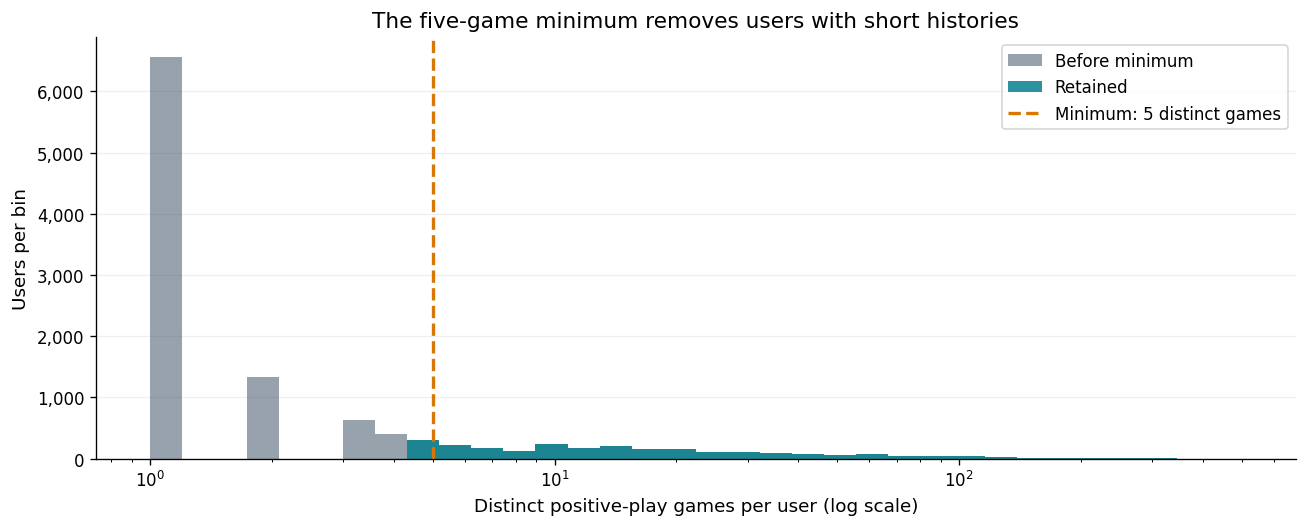

,Minimum games (diagnostic only),Users retained,Interactions retained
0,2,4791,63915
1,3,3466,61265
2,5,2436,57774
3,10,1477,51521
4,20,800,42244


In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
bins = np.geomspace(1, history_sizes_before.max() + 1, 35)
ax.hist(history_sizes_before, bins=bins, color=SLATE, alpha=0.6, label="Before minimum")
ax.hist(history_sizes_after, bins=bins, color=TEAL, alpha=0.85, label="Retained")
ax.axvline(config.min_games_per_user, color=AMBER, linestyle="--", linewidth=2,
           label=f"Minimum: {config.min_games_per_user} distinct games")
ax.set(xscale="log", xlabel="Distinct positive-play games per user (log scale)",
       ylabel="Users per bin", title="The five-game minimum removes users with short histories")
ax.yaxis.set_major_formatter(integer_axis)
ax.grid(axis="y", alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

display(pd.DataFrame([
    {"Minimum games (diagnostic only)": minimum,
     "Users retained": int(history_sizes_before.ge(minimum).sum()),
     "Interactions retained": int(history_sizes_before[history_sizes_before.ge(minimum)].sum())}
    for minimum in sorted({2, 3, config.min_games_per_user, 10, 20})
]))

## 5. Account for every row removed

Each line below describes the population **after** that step. The normalization line
is included even though it changes title identities without removing rows. The
number of games includes only titles still represented at that step.

This is a filtering audit, not a funnel of independent user decisions: one user can
have purchase records removed while keeping their play records.

,Step,Rows before,Rows removed,Rows after,Users after,Games after,Why
0,Raw CSV,200000,0,200000,12393,5155,Starting activity records
1,Play behavior only,200000,129511,70489,11350,3600,Purchase value is not playtime
2,Positive hours only,70489,0,70489,11350,3600,No positive engagement at hours <= 0
3,Normalized titles,70489,0,70489,11350,3598,Unify title identity; remove no rows
4,Unique user/game pairs,70489,15,70474,11350,3598,Keep maximum cumulative hours per pair
5,Users with >= 5 games,70474,12700,57774,2436,3542,Enough history for training plus one test game


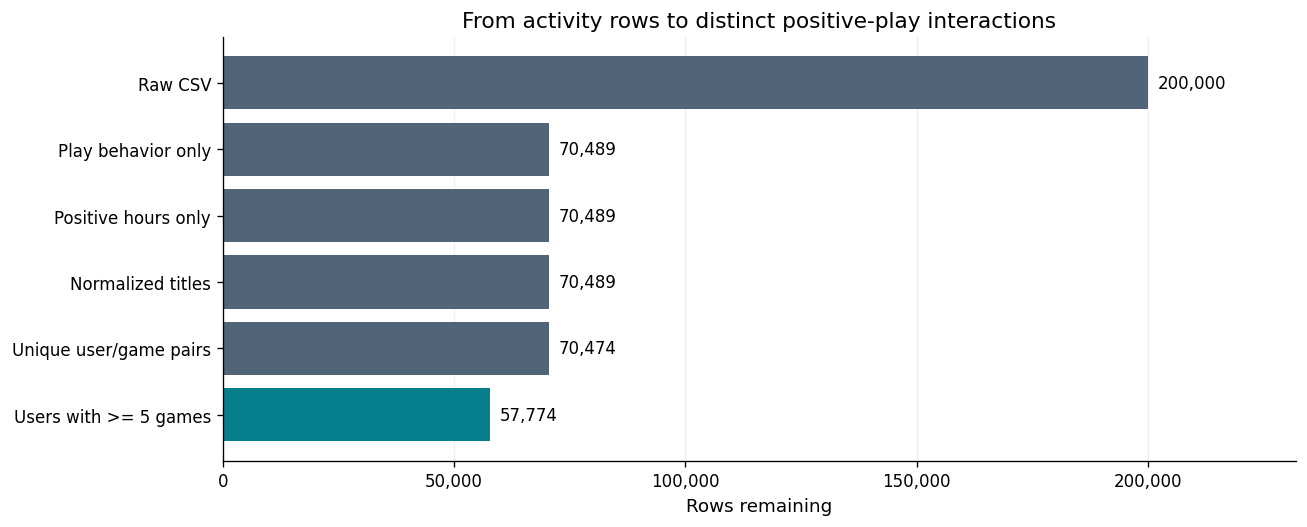

In [7]:
stages = [
    ("Raw CSV", raw, "Starting activity records"),
    ("Play behavior only", play, "Purchase value is not playtime"),
    ("Positive hours only", play.loc[play.value.gt(0)], "No positive engagement at hours <= 0"),
    ("Normalized titles", positive, "Unify title identity; remove no rows"),
    ("Unique user/game pairs", deduplicated, "Keep maximum cumulative hours per pair"),
    (f"Users with >= {config.min_games_per_user} games", filtered, "Enough history for training plus one test game"),
]
audit_rows = []
previous = len(raw)
for name, frame, reason in stages:
    audit_rows.append({
        "Step": name, "Rows before": previous, "Rows removed": previous - len(frame),
        "Rows after": len(frame), "Users after": frame.user_id.nunique(),
        "Games after": frame.game_title.nunique(), "Why": reason,
    })
    previous = len(frame)
audit = pd.DataFrame(audit_rows)
assert audit["Rows removed"].sum() + len(filtered) == len(raw)
display(audit)

fig, ax = plt.subplots(figsize=(11, 4.5))
bars = ax.barh(audit.Step, audit["Rows after"], color=[SLATE] * (len(audit) - 1) + [TEAL])
ax.bar_label(bars, labels=[f"{value:,}" for value in audit["Rows after"]], padding=6)
ax.invert_yaxis()
ax.set(xlabel="Rows remaining", title="From activity rows to distinct positive-play interactions",
       xlim=(0, len(raw) * 1.16))
ax.xaxis.set_major_formatter(integer_axis)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

## 6. Explore the hours we kept

We keep positive outliers rather than silently trimming them. The two plots show
the **same retained interactions**: the first uses a linear hours axis, while the
second uses logarithmically spaced bins and a log hours axis to reveal the tail.
Bin widths therefore differ between the panels.

Hours measure engagement imperfectly: idle time, AFK farming, and games left running
can inflate them. A large mean relative to the median is a reason to examine scale,
not a reason to delete the largest observations without evidence.

,Hours per interaction
count,"57,774.00"
mean,40.59
std,193.01
min,0.10
25%,1.00
50%,4.40
75%,17.90
90%,64.00
99%,730.54
max,"10,442.00"


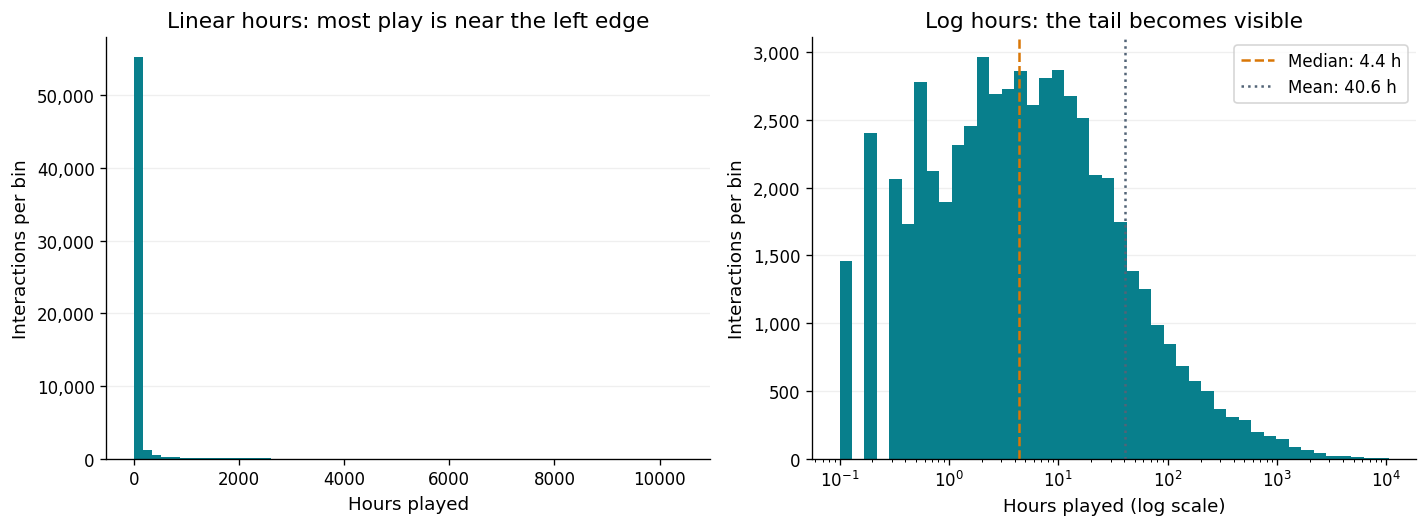

**Largest retained observations (inspection only; none removed):**

,user_id,display_title,hours
0,100630947,Dota 2,"10,442.00"
1,52567955,Dota 2,"6,964.00"
2,86256882,Dota 2,"6,015.00"
3,12660489,Dota 2,"5,970.00"
4,67694595,Dota 2,"5,608.00"
5,106099216,Sid Meier's Civilization V,"5,483.00"
6,20207081,Dota 2,"4,845.00"
7,167194020,FINAL FANTASY XIV A Realm Reborn,"4,835.00"


**Scale illustration for the planned ALS baseline:**

,Original hours,log(1 + hours)
0,0.10,0.10
1,1.00,0.69
2,10.00,2.40
3,100.00,4.62
4,"1,000.00",6.91
5,"10,000.00",9.21


In [8]:
display(filtered.hours.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).to_frame("Hours per interaction"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(filtered.hours, bins=60, color=TEAL)
axes[0].set(title="Linear hours: most play is near the left edge", xlabel="Hours played", ylabel="Interactions per bin")
log_bins = np.geomspace(filtered.hours.min(), filtered.hours.max(), 45)
axes[1].hist(filtered.hours, bins=log_bins, color=TEAL)
axes[1].set(xscale="log", title="Log hours: the tail becomes visible", xlabel="Hours played (log scale)", ylabel="Interactions per bin")
axes[1].axvline(filtered.hours.median(), color=AMBER, linestyle="--", label=f"Median: {filtered.hours.median():.1f} h")
axes[1].axvline(filtered.hours.mean(), color=SLATE, linestyle=":", label=f"Mean: {filtered.hours.mean():.1f} h")
axes[1].legend()
for ax in axes:
    ax.yaxis.set_major_formatter(integer_axis)
    ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

display(Markdown("**Largest retained observations (inspection only; none removed):**"))
display(filtered.nlargest(8, "hours").assign(display_title=lambda frame: frame.game_title.map(display_titles))[
    ["user_id", "display_title", "hours"]
].reset_index(drop=True))
display(Markdown("**Scale illustration for the planned ALS baseline:**"))
illustrative_hours = pd.Series([0.1, 1, 10, 100, 1000, 10000], name="Original hours")
display(pd.DataFrame({"Original hours": illustrative_hours, "log(1 + hours)": np.log1p(illustrative_hours)}))

The pipeline saves **raw hours**. The planned ALS baseline will calculate
`log(1 + hours)` from its training matrix; the table above only illustrates why that
transformation compresses scale. No model has been fitted to the full dataset here.

## 7. Inspect the persisted game IDs

IDs are zero-based embedding indices, not popularity ranks. On the first run, sorted
normalized titles receive consecutive IDs. Future runs reuse the saved mapping and
append new titles without renumbering old ones. Preserve this file with any trained
model. Missing titles keep their IDs and become inactive in the current catalog.

The mapping covers the filtered catalog, including test positives. It provides item
identity only; popularity and other learned statistics must come from training rows.

In [9]:
mapping_path = config.processed_dir / "game_mapping.json"
mapping = json.loads(mapping_path.read_text(encoding="utf-8"))
rebuilt_mapping = build_game_mapping(filtered.game_title, mapping_path)  # Reads, but does not write.
assert mapping == rebuilt_mapping
assert sorted(mapping.values()) == list(range(len(mapping)))
assert hashlib.sha256(mapping_path.read_bytes()).hexdigest() == stats["mapping_sha256"]
games = pd.read_csv(config.processed_dir / "games.csv", keep_default_na=False)
display(games.head(10))
display(pd.Series({
    "Persistent mapping entries": len(mapping),
    "Active games in this dataset": filtered.game_title.nunique(),
    "Inactive mapping entries": int(games.is_active.eq(0).sum()),
    "Mapping SHA-256 verified": True,
}, name="ID mapping").to_frame())

,game_id,game_title,display_title,is_active
0,0,007 legends,007 Legends,1
1,1,0rbitalis,0RBITALIS,1
2,2,1... 2... 3... kick it! (drop that beat like an ugly baby),1... 2... 3... KICK IT! (Drop That Beat Like an Ugly Baby),1
3,3,10 second ninja,10 Second Ninja,1
4,4,"10,000,000","10,000,000",1
5,5,100% orange juice,100% Orange Juice,1
6,6,1000 amps,1000 Amps,1
7,7,12 labours of hercules,12 Labours of Hercules,1
8,8,12 labours of hercules ii the cretan bull,12 Labours of Hercules II The Cretan Bull,1
9,9,12 labours of hercules iii girl power,12 Labours of Hercules III Girl Power,1


,ID mapping
Persistent mapping entries,3542
Active games in this dataset,3542
Inactive mapping entries,0
Mapping SHA-256 verified,True


## 8. Walk through random leave-one-out

For **each retained user**:

1. Sort their distinct games by normalized title. This makes the procedure independent
   of CSV row order; alphabetical order is not a claim about when games were played.
2. Initialize `random.Random(f"{seed}:{user_id}")`.
3. Choose one index uniformly with `randrange(number_of_games)`.
4. Put that game and its hours in test; keep every other game in the training history.

Hours do not determine which game is selected. The held-out game is not necessarily
the favorite or the most recent. A user-specific seed keeps an existing user's split
stable when an unrelated user is added or removed.

This is **not a global 80/20 split**: a five-game user contributes one test and four
training interactions, while a twenty-game user contributes one test and nineteen
training interactions. Each user has equal representation in the test set.

In [10]:
train_interactions, test_interactions = leave_one_out(filtered_interactions, config.seed)
train = pd.DataFrame([asdict(row) for row in train_interactions])
test = pd.DataFrame([asdict(row) for row in test_interactions])

display(pd.DataFrame([
    {"Split": "Train", "Interactions": len(train), "Users": train.user_id.nunique(), "Games": train.game_title.nunique()},
    {"Split": "Test", "Interactions": len(test), "Users": test.user_id.nunique(), "Games": test.game_title.nunique()},
]))
display(Markdown(f"The test set is **{len(test) / len(filtered):.2%}** of retained interactions: one per user."))

example_user = history_sizes_after.sort_values(kind="stable").index[0]
example = filtered.loc[filtered.user_id.eq(example_user)].sort_values("game_title").reset_index(drop=True)
chosen_index = random.Random(f"{config.seed}:{example_user}").randrange(len(example))
example["sorted_index"] = example.index
example["display_title"] = example.game_title.map(display_titles)
example["split"] = np.where(example.index == chosen_index, "TEST: held out", "TRAIN: user history")
actual_test_title = test.loc[test.user_id.eq(example_user), "game_title"].item()
assert example.loc[chosen_index, "game_title"] == actual_test_title
display(Markdown(
    f"**User {example_user}:** seed string `{config.seed}:{example_user}` selects index "
    f"**{chosen_index}** from **{len(example)}** distinct games."
))
display(example[["sorted_index", "user_id", "display_title", "hours", "split"]])

,Split,Interactions,Users,Games
0,Train,55338,2436,3519
1,Test,2436,2436,762


The test set is **4.22%** of retained interactions: one per user.

**User 100833937:** seed string `42:100833937` selects index **3** from **5** distinct games.

,sorted_index,user_id,display_title,hours,split
0,0,100833937,Cities XL 2012,57.00,TRAIN: user history
1,1,100833937,Grand Theft Auto IV,65.00,TRAIN: user history
2,2,100833937,Portal,5.90,TRAIN: user history
3,3,100833937,Portal 2,15.10,TEST: held out
4,4,100833937,Puddle,0.40,TRAIN: user history


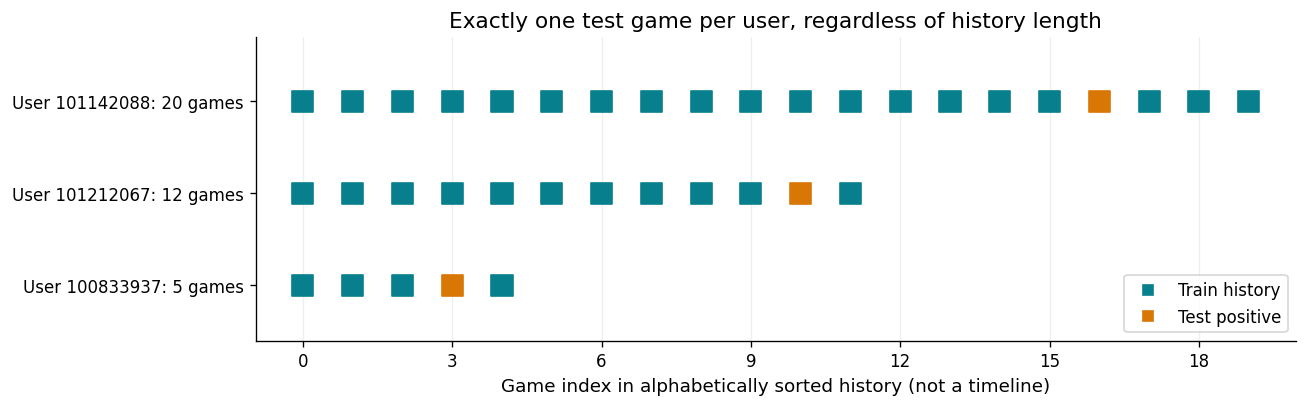

In [11]:
# Compare several history sizes. Positions show alphabetical order, never time.
selected_users = []
for target_size in [config.min_games_per_user, 12, 20]:
    distances = (history_sizes_after - target_size).abs().sort_values(kind="stable")
    selected_users.append(next(user for user in distances.index if user not in selected_users))

fig, ax = plt.subplots(figsize=(11, 3.5))
labels = []
for y, user_id in enumerate(selected_users):
    history = filtered.loc[filtered.user_id.eq(user_id)].sort_values("game_title")
    held_out_title = test.loc[test.user_id.eq(user_id), "game_title"].item()
    colors = [AMBER if title == held_out_title else TEAL for title in history.game_title]
    ax.scatter(np.arange(len(history)), [y] * len(history), c=colors, marker="s", s=160)
    labels.append(f"User {user_id}: {len(history)} games")
ax.set_yticks(range(len(selected_users)), labels)
ax.set(xlabel="Game index in alphabetically sorted history (not a timeline)",
       title="Exactly one test game per user, regardless of history length", ylim=(-0.6, 2.7))
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(handles=[
    Line2D([], [], color=TEAL, marker="s", linestyle="None", label="Train history"),
    Line2D([], [], color=AMBER, marker="s", linestyle="None", label="Test positive"),
], loc="lower right")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

## 9. Prove the split and saved files agree

These assertions are part of the walkthrough, not just reassuring text. The relevant
leakage condition is a repeated **user/game pair** across splits: the same game may
legitimately appear in another user's training history.

We check one positive for every user, complete coverage of the filtered data, at
least four training games per user, preserved hours/IDs, repeatability, and equality
with the actual saved CSVs. This checks split leakage; prompt-level leakage needs
its own test when the verbalizer is built.

In [12]:
pair_columns = ["user_id", "game_title"]
pair_set = lambda frame: set(frame[pair_columns].itertuples(index=False, name=None))
train_pairs, test_pairs, filtered_pairs = pair_set(train), pair_set(test), pair_set(filtered)
train_sizes = train.groupby("user_id").size()
test_sizes = test.groupby("user_id").size()
shuffled = filtered_interactions.copy()
random.Random(123).shuffle(shuffled)
replayed_train, replayed_test = leave_one_out(shuffled, config.seed)

checks = {
    "No duplicate pairs in filtered data": len(filtered_pairs) == len(filtered),
    "No train/test user-game overlap": not (train_pairs & test_pairs),
    "Train plus test covers every retained pair": train_pairs | test_pairs == filtered_pairs,
    "Exactly one test positive per user": test_sizes.eq(1).all() and set(test_sizes.index) == set(history_sizes_after.index),
    "Every user retains enough training games": train_sizes.ge(config.min_games_per_user - 1).all(),
    "No rows added or lost by split": len(train) + len(test) == len(filtered),
    "Shuffling input preserves the split": replayed_train == train_interactions and replayed_test == test_interactions,
}

for filename, expected in [("interactions.csv", filtered), ("train.csv", train), ("test.csv", test)]:
    saved = pd.read_csv(config.processed_dir / filename, dtype={"user_id": "string"}, keep_default_na=False)
    expected_with_ids = expected.assign(game_id=expected.game_title.map(mapping))[
        ["user_id", "game_id", "game_title", "hours"]
    ]
    pd.testing.assert_frame_equal(
        saved.sort_values(pair_columns).reset_index(drop=True),
        expected_with_ids.sort_values(pair_columns).reset_index(drop=True), check_dtype=False,
    )
    checks[f"Saved {filename} matches recomputed rows, hours, and IDs"] = True

assert all(checks.values()), checks
display(pd.DataFrame({"Check": checks.keys(), "Passed": checks.values()}))

,Check,Passed
0,No duplicate pairs in filtered data,True
1,No train/test user-game overlap,True
2,Train plus test covers every retained pair,True
3,Exactly one test positive per user,True
4,Every user retains enough training games,True
5,No rows added or lost by split,True
6,Shuffling input preserves the split,True
7,"Saved interactions.csv matches recomputed rows, hours, and IDs",True
8,"Saved train.csv matches recomputed rows, hours, and IDs",True
9,"Saved test.csv matches recomputed rows, hours, and IDs",True


## 10. Inspect training popularity and unsupported test games

Popularity is a future baseline, so the descriptive counts below use **training
interactions only**. Since pairs are unique, a game's play count equals its distinct
training-user count. This plot is an EDA view, not a baseline evaluation.

A random holdout can also leave a rare game with **zero positive training
interactions**. Its ID exists, but no user has provided training evidence of liking
it. We retain and report these cases instead of resampling the test set. The baseline
checkpoint must make their treatment and metric coverage explicit.

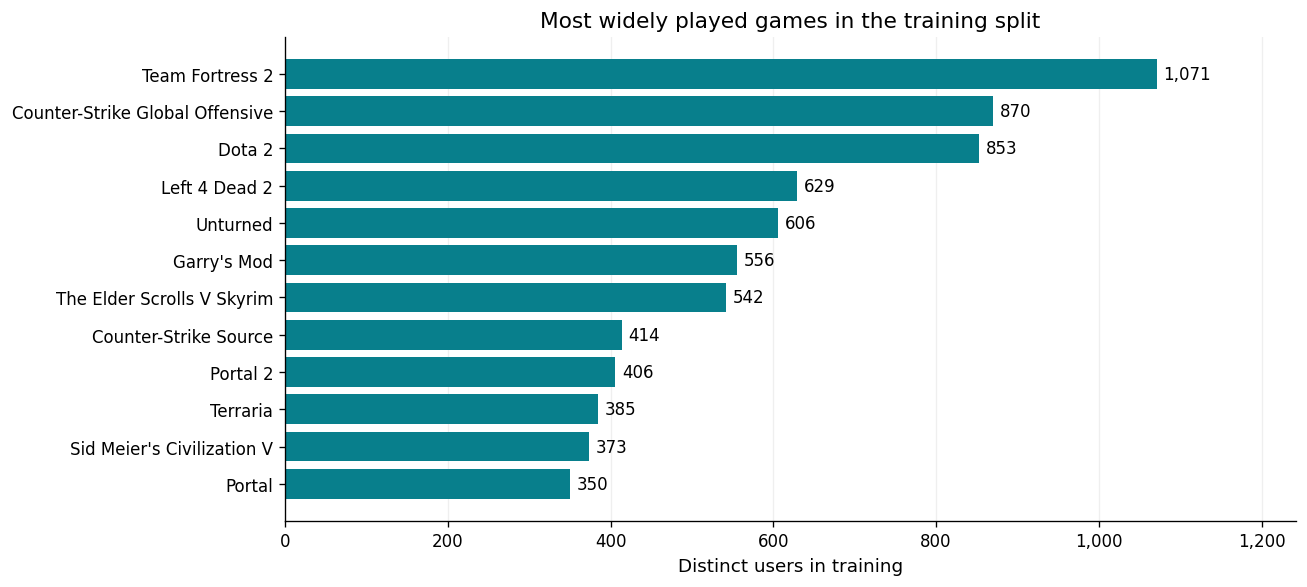

,Training coverage
Games present in training,3519
Test games with no training interactions,23
Test users whose positive has no training interactions,25
Share of test users affected,1.03%


,game_id,display_title,test_users,test_hours_total
0,937,Dream Of Mirror Online,2,3.40
1,1224,Fork Parker's Holiday Profit Hike,2,0.80
2,276,Bard's Gold,1,119.00
3,473,Call of Duty Black Ops - Multiplayer OSX,1,60.00
4,554,Chris Sawyer's Locomotion,1,2.60
5,791,Decay - The Mare,1,5.00
6,843,Devils Share,1,0.70
7,1009,Eidolon,1,0.20
8,1074,European Ship Simulator,1,0.40
9,1175,Final Slam 2,1,0.10


In [13]:
popularity = train.groupby("game_title").size().sort_values(ascending=False)
top = popularity.head(12).sort_values()
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh([display_titles[title] for title in top.index], top.values, color=TEAL)
ax.bar_label(bars, labels=[f"{count:,}" for count in top.values], padding=4)
ax.set(xlabel="Distinct users in training", title="Most widely played games in the training split",
       xlim=(0, top.max() * 1.16))
ax.xaxis.set_major_formatter(integer_axis)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

unseen_titles = set(test.game_title) - set(train.game_title)
unsupported = test.loc[test.game_title.isin(unseen_titles)].copy()
unseen_summary = unsupported.groupby("game_title").agg(
    test_users=("user_id", "nunique"), test_hours_total=("hours", "sum"),
).reset_index()
unseen_summary["game_id"] = unseen_summary.game_title.map(mapping)
unseen_summary["display_title"] = unseen_summary.game_title.map(display_titles)
display(pd.Series({
    "Games present in training": train.game_title.nunique(),
    "Test games with no training interactions": len(unseen_titles),
    "Test users whose positive has no training interactions": len(unsupported),
    "Share of test users affected": f"{len(unsupported) / len(test):.2%}",
}, name="Training coverage").to_frame())
display(unseen_summary[["game_id", "display_title", "test_users", "test_hours_total"]].sort_values(
    ["test_users", "display_title"], ascending=[False, True],
).reset_index(drop=True))

## 11. Reconcile with `stats.json` and review the checkpoint

The final assertions verify that this walkthrough describes the same source,
configuration, mapping, and outputs as the saved pipeline run. If they fail after a
configuration change, regenerate the processed data and restart the notebook kernel.

**Limits to carry into evaluation:** no temporal ordering; a population restricted to
users with enough played games; a historical, small catalog; hours as a noisy
engagement proxy; unsupported rare titles; and no online evaluation.

No popularity model, ALS model, verbalizer, or model scores are produced here. Those
remain subsequent review checkpoints in `PROJECT_CONTEXT.md`.

In [14]:
assert stats["source"]["sha256"] == hashlib.sha256(config.raw_path.read_bytes()).hexdigest()
assert stats["seed"] == config.seed
assert stats["min_games_per_user"] == config.min_games_per_user
assert stats["raw"] == raw_stats
assert stats["n_users"] == filtered.user_id.nunique()
assert stats["n_games"] == filtered.game_title.nunique()
assert stats["n_interactions"] == len(filtered)
assert stats["filtering"]["n_users_dropped"] == len(removed_users)
assert stats["filtering"]["n_interactions_dropped_for_min_games"] == len(removed_for_history)
assert stats["split"]["n_train"] == len(train)
assert stats["split"]["n_test"] == len(test)
assert stats["split"]["n_train_games"] == train.game_title.nunique()
assert stats["split"]["n_test_games_unseen_in_train"] == len(unseen_titles)
assert stats["split"]["n_test_users_with_unseen_game"] == len(unsupported)
assert stats["split"]["test_only_game_ids"] == sorted(mapping[title] for title in unseen_titles)
assert np.isclose(stats["hours"]["mean"], filtered.hours.mean())
assert np.isclose(stats["hours"]["median"], filtered.hours.median())
assert np.isclose(stats["hours"]["p99"], filtered.hours.quantile(0.99))

display(Markdown(
    f"**Checkpoint verified.** {len(raw):,} source rows become **{len(filtered):,} distinct "
    f"positive-play interactions** across **{filtered.user_id.nunique():,} users** and "
    f"**{filtered.game_title.nunique():,} active games**. The persisted mapping has "
    f"**{len(mapping):,} IDs**. The split contains **{len(train):,} training rows** and "
    f"**{len(test):,} test positives**, with no user/game overlap. "
    f"**{len(unsupported):,} test users** have a positive with no training interactions. "
    "Every filtering removal is accounted for above, and the saved artifacts agree."
))

**Checkpoint verified.** 200,000 source rows become **57,774 distinct positive-play interactions** across **2,436 users** and **3,542 active games**. The persisted mapping has **3,542 IDs**. The split contains **55,338 training rows** and **2,436 test positives**, with no user/game overlap. **25 test users** have a positive with no training interactions. Every filtering removal is accounted for above, and the saved artifacts agree.